# Analisi Prodotti - Azienda G

## 1. Web Scraping e Raccolta Dati
In questa fase eseguiamo il web scraping del catalogo online dell'Azienda G tramite le librerie `requests` e `BeautifulSoup`. L'obiettivo è raccogliere le informazioni fondamentali per ogni referenza disponibile nella pagina. 

A differenza di altri competitor, per questo brand isoliamo tre chiavi principali:
* **Nome del prodotto** (Scarpa)
* **Categoria** di origine (es. "sneaker slip in")
* **Prezzo** di vendita

I dati vengono temporaneamente salvati in liste per la successiva conversione in formato tabellare.

In [4]:
from Library import *
load_dotenv()
URL_G = os.getenv("URL_G")

Lista_scarpe_G = [] 
Prezzo_scarpe_G = []
Categoria_scarpe_G = []

response_G = requests.get(URL_G)
html_G = response_G.text
soup_G = bs(html_G)
    
card_prodotto_G = soup_G.find_all("div", class_="product-tile")

for card in card_prodotto_G:
    nome_prodotto_G = card.find("a", attrs={"class": "link"})
    nome_G = nome_prodotto_G.get_text(strip=True)
   
    category_prodotto_G = card.find("div", attrs={"class": "category"})
    category_G = category_prodotto_G.get_text(strip=True)
    
    prezzo_prodotto_G = card.find("div", attrs={"class": "price"})
    prezzo_G = prezzo_prodotto_G.get_text(strip=True)

    Lista_scarpe_G.append(nome_G)
    Prezzo_scarpe_G.append(prezzo_G)
    Categoria_scarpe_G.append(category_G)
        
    #print(f"{nome_G} | {category_G} | {prezzo_G}")


#print(len(Lista_scarpe_G,))
#print(len(Prezzo_scarpe_G))
#print(len(Categoria_scarpe_G))
print("Fine scraping")

Fine scraping


In [5]:
Dict_G = {"Scarpe":Lista_scarpe_G,"Prezzo":Prezzo_scarpe_G,"Categoria":Categoria_scarpe_G}
df_G = pd.DataFrame(Dict_G)
df_G

,Scarpe,Prezzo,Categoria
0,SPHERICA PLUS UOMO,"€119,90",Sneaker slip in
1,SPHERICA PLUS UOMO,"€119,90",Sneaker slip in
2,SPHERICA PLUS UOMO,"€109,90",Sneaker slip in
3,WELLS UOMO,"€109,90",Sneakers basse
4,SPHERICA PLUS UOMO,"€119,90",Sneaker slip in
...,...,...,...
284,SPHERICA ECUB-1 B UOMO,"€139,90",Sneakers basse
285,BALTMOORE UOMO,"€99,90",Sneakers basse
286,SPHERICA PLUS UOMO,"€109,90",Sneaker slip in
287,SPHERICA PLUS UOMO,"€109,90",Sneaker slip in


## 2. Data Cleaning e Formattazione Testo
Dopo aver consolidato i dati nel DataFrame `df_G`, procediamo con la normalizzazione dei valori:

1. **Pulizia Numerica:** Rimuoviamo il simbolo della valuta ("€") e gli spazi, formattiamo i separatori decimali (sostituendo la virgola col punto) e convertiamo la colonna `Prezzo` in formato `float`.
2. **Standardizzazione Stringhe:** Uniformiamo il testo per evitare discrepanze causate da maiuscole/minuscole inserite casualmente a sistema. Applichiamo il formato *Title Case* ai nomi dei prodotti e *Capitalize* alle categorie.

In [6]:
print(df_G.info())
#Rimuoviamo il simbolo dell'Euro e gli eventuali spazi vuoti
df_G["Prezzo"] = df_G["Prezzo"].str.replace("€", "", regex=False).str.strip()
df_G["Prezzo"] = df_G["Prezzo"].str.replace(".", "", regex=False)
df_G["Prezzo"] = df_G["Prezzo"].str.replace(",", ".", regex=False)

#convertiamo in float
df_G["Prezzo"] = df_G["Prezzo"].astype(float)
print(df_G.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Scarpe     289 non-null    object
 1   Prezzo     289 non-null    object
 2   Categoria  289 non-null    object
dtypes: object(3)
memory usage: 6.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Scarpe     289 non-null    object 
 1   Prezzo     289 non-null    float64
 2   Categoria  289 non-null    object 
dtypes: float64(1), object(2)
memory usage: 6.9+ KB
None


In [7]:
df_G['Scarpe'] = df_G['Scarpe'].str.strip().str.title() #trasformiamo in maiuscolo la prima lettera di ogni modello scarpa e rendiamo minuscolo il resto
df_G['Categoria'] = df_G['Categoria'].str.strip().str.capitalize() #trasformiamo in maiuscolo solo la primissima lettera dell'intera stringa, rendendo tutto il resto minuscolo.

## 3. Deduplicazione del Dataset
Applichiamo il metodo `.drop_duplicates()` per pulire il dataset, riducendo drasticamente il numero di righe e isolando esclusivamente i prodotti unici per non falsare le successive medie di prezzo.

In [8]:
print(df_G.duplicated())
df_G.drop_duplicates()
df_G

0      False
1       True
2      False
3      False
4       True
       ...  
284     True
285     True
286     True
287     True
288     True
Length: 289, dtype: bool


,Scarpe,Prezzo,Categoria
0,Spherica Plus Uomo,119.9,Sneaker slip in
1,Spherica Plus Uomo,119.9,Sneaker slip in
2,Spherica Plus Uomo,109.9,Sneaker slip in
3,Wells Uomo,109.9,Sneakers basse
4,Spherica Plus Uomo,119.9,Sneaker slip in
...,...,...,...
284,Spherica Ecub-1 B Uomo,139.9,Sneakers basse
285,Baltmoore Uomo,99.9,Sneakers basse
286,Spherica Plus Uomo,109.9,Sneaker slip in
287,Spherica Plus Uomo,109.9,Sneaker slip in


In [9]:
df_G.to_csv("Azienda G.csv", index=False)

print("File CSV salvato con successo!")

File CSV salvato con successo!


In [6]:
from Library import * 
df_G = pd.read_csv("Azienda G.csv")

In [8]:
df_G = df_G.drop_duplicates()
print(f"Righe dopo deduplicazione: {len(df_G)}")
print(f"(erano {289} prima, {289 - len(df_G)} duplicati rimossi)")

Righe dopo deduplicazione: 91
(erano 289 prima, 198 duplicati rimossi)


## 4. Mappatura Tassonomica
Per rendere l'Azienda G comparabile con i competitor, traduciamo le categorie originali del sito in una struttura standardizzata a due livelli: **Macro_categoria** e **Micro_categoria**.

Utilizziamo un dizionario di mappatura (`MACRO_MICRO_G`) accoppiato a una funzione `lambda`. Eventuali voci non previste verranno classificate temporaneamente come "Altro" per permetterci di intercettarle e aggiornare il dizionario.

In [9]:
# Mappa ogni categoria originale in Macro e Micro categoria

MACRO_MICRO_G = {
    "sneaker slip in":("Sneakers","Sneakers slip-in"),
    "sneakers basse":("Sneakers","Sneakers basse"),
    "sneakers basse vintage": ("Sneakers","Sneakers vintage"),
    "sneakers in tessuto":("Sneakers","Sneakers basse"),
    "sneakers senza lacci":("Sneakers","Sneakers basse"),
    "espadrillas":("Ciabatte & Pantofole", "Espadrillas"),
    "scarpe in pelle":("Scarpe eleganti","Stringate / Derby"),
    "scarpe camoscio":("Scarpe eleganti","Stringate / Derby"),
    "mocassini in pelle":("Mocassini","Mocassini"),
    "mocassini scamosciati":("Mocassini","Mocassini"),
    "mocassini da barca":("Mocassini","Boat shoes"),
    "sandali aperti":("Sandali","Sandali aperti"),
    "sandali chiusi":("Sandali","Sandali chiusi"),
    "sandali sportivi":("Sandali","Sandali sportivi"),
    "sandali infradito":("Sandali","Sandali infradito"),
    "ciabatte":("Ciabatte & Pantofole", "Ciabatte"),
}

mapped = df_G["Categoria"].str.strip().str.lower().apply(
    lambda x: MACRO_MICRO_G.get(x, ("Altro", "Altro"))
)

df_G["Macro_categoria"] = mapped.apply(lambda x: x[0])
df_G["Micro_categoria"]  = mapped.apply(lambda x: x[1])

non_mappate = df_G[df_G["Macro_categoria"] == "Altro"]["Categoria"].unique()
print(f"Categorie non mappate: {non_mappate if len(non_mappate) else 'Nessuna'}")
print(df_G[["Macro_categoria","Micro_categoria"]].value_counts())

Categorie non mappate: Nessuna ✓
Macro_categoria       Micro_categoria  
Sneakers              Sneakers basse       29
Scarpe eleganti       Stringate / Derby    16
Mocassini             Mocassini            13
Sneakers              Sneakers slip-in     10
Ciabatte & Pantofole  Ciabatte              8
Sandali               Sandali aperti        4
                      Sandali sportivi      4
Sneakers              Sneakers vintage      3
Ciabatte & Pantofole  Espadrillas           1
Mocassini             Boat shoes            1
Sandali               Sandali chiusi        1
                      Sandali infradito     1
Name: count, dtype: int64


## 5. Exploratory Data Analysis

### 5.1 Distribuzione dell'Assortimento
Analizziamo visivamente il peso delle diverse categorie nel catalogo dell'Azienda G. I grafici a barre orizzontali ci permettono di inquadrare immediatamente la vocazione del brand, evidenziando le macro-famiglie predominanti e scendendo poi nel dettaglio delle micro-categorie.

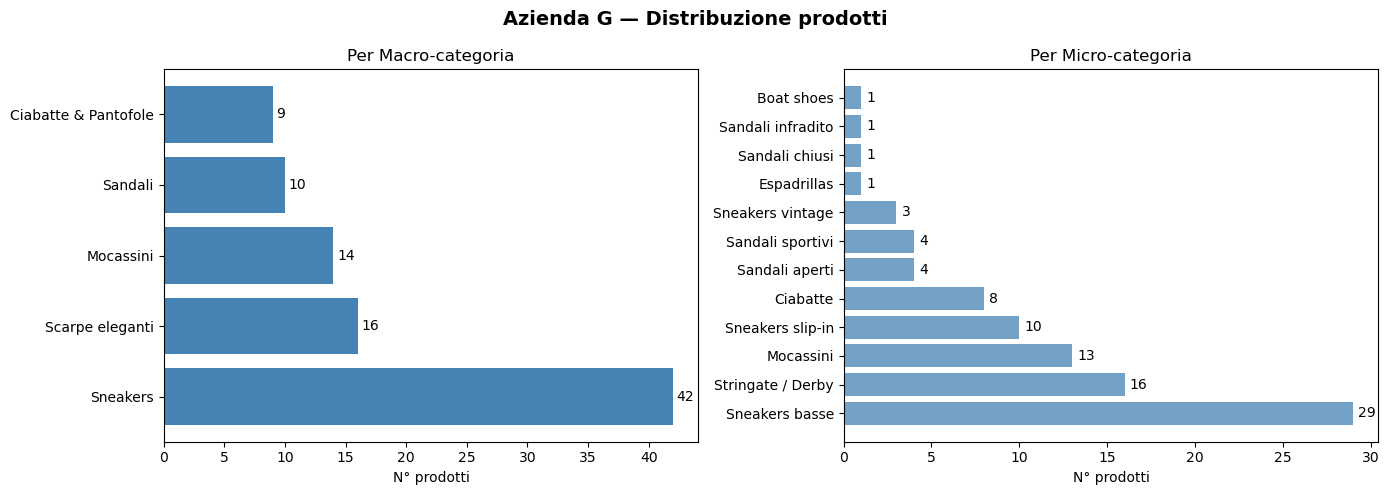

In [24]:
fig, n1 = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Azienda G — Distribuzione prodotti", fontsize=14, fontweight="bold")

# Macro categoria
macro_counts = df_G["Macro_categoria"].value_counts()
n1[0].barh(macro_counts.index, macro_counts.values, color="steelblue")
n1[0].set_title("Per Macro-categoria")
n1[0].set_xlabel("N° prodotti")
for i, v in enumerate(macro_counts.values):n1[0].text(v + 0.3, i, str(v), va="center")

# Micro categoria
micro_counts = df_G["Micro_categoria"].value_counts()
n1[1].barh(micro_counts.index, micro_counts.values, color="steelblue", alpha=0.75)
n1[1].set_title("Per Micro-categoria")
n1[1].set_xlabel("N° prodotti")
for i, v in enumerate(micro_counts.values):n1[1].text(v + 0.3, i, str(v), va="center")

plt.tight_layout()
plt.show()

### 5.2 Analisi Statistica dei Prezzi
Esaminiamo le metriche di pricing. Non avendo rilevato sconti espliciti in fase di scraping, ci concentriamo sul posizionamento medio del brand. Estrapoliamo:
* La baseline generale del catalogo (media, mediana, deviazione standard).
* Il posizionamento per singola Macro e Micro categoria, per capire quali segmenti trainano il valore (es. i Mocassini) e quali fungono da entry-level (es. i Sandali).

In [16]:
print("--- Statistiche prezzi generali ---")
print(df_G["Prezzo"].describe().round(2))

print("\n--- Prezzi per Macro-categoria ---")
print(df_G.groupby("Macro_categoria")["Prezzo"].agg(Media="mean", Minimo="min", Massimo="max", N="count").round(2))

print("\n--- Prezzi per Micro-categoria ---")
print(df_G.groupby("Micro_categoria")["Prezzo"].agg(Media="mean", Minimo="min", Massimo="max", N="count").round(2))

--- Statistiche prezzi generali ---
count     91.00
mean     115.40
std       26.73
min       69.90
25%       99.90
50%      109.90
75%      135.00
max      199.90
Name: Prezzo, dtype: float64

--- Prezzi per Macro-categoria ---
                       Media  Minimo  Massimo   N
Macro_categoria                                  
Ciabatte & Pantofole   84.34    69.9     99.9   9
Mocassini             132.06    99.9    199.9  14
Sandali                83.90    79.9     89.9  10
Scarpe eleganti       134.60    99.9    199.9  16
Sneakers              116.69    89.9    169.9  42

--- Prezzi per Micro-categoria ---
                    Media  Minimo  Massimo   N
Micro_categoria                               
Boat shoes          99.90    99.9     99.9   1
Ciabatte            83.65    69.9     99.9   8
Espadrillas         89.90    89.9     89.9   1
Mocassini          134.53   109.9    199.9  13
Sandali aperti      82.40    79.9     89.9   4
Sandali chiusi      79.90    79.9     79.9   1
Sandali i

### 5.3 Distribuzione e Outlier di Prezzo
Per confermare i dati tabellari, tracciamo:
* Un **istogramma** che mostra la distribuzione di frequenza dei prezzi e la media globale. Utile per identificare eventuali conformazioni bimodali (presenza di due fasce di prezzo distinte).
* Un **boxplot raggruppato** per valutare lo scostamento interquartile all'interno delle Macro-categorie e individuare visivamente i prodotti premium (*outlier*).

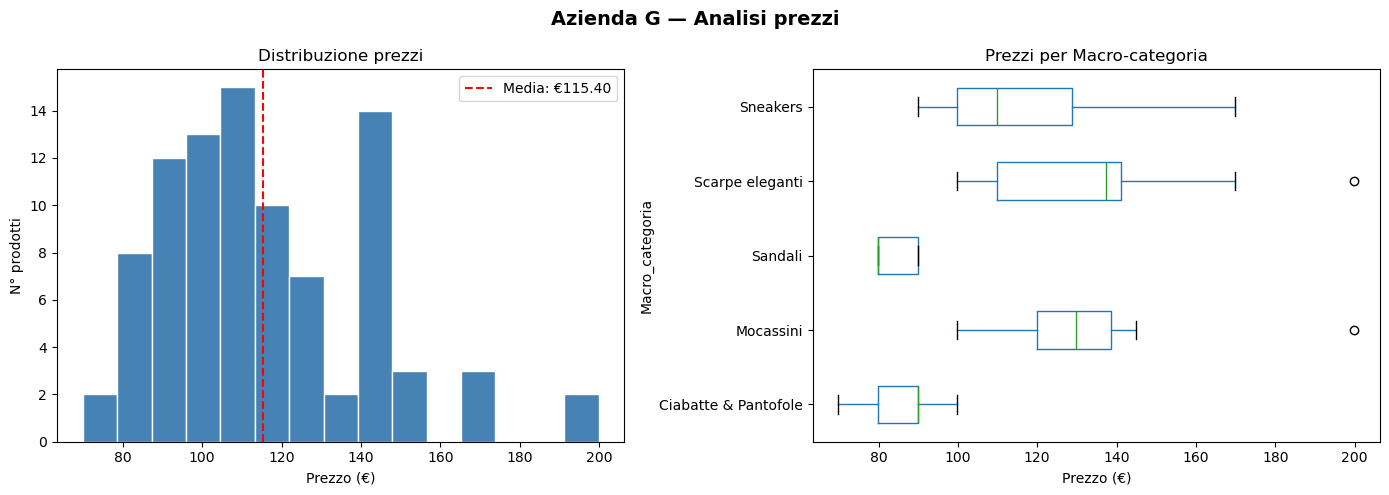

In [27]:
fig, n2 = plt.subplots(1, 2, figsize=(14, 5))


# Istogramma prezzi
n2[0].hist(df_G["Prezzo"], bins=15, color="steelblue", edgecolor="white")
n2[0].axvline(df_G["Prezzo"].mean(), color="red", linestyle="--", label=f'Media: €{df_G["Prezzo"].mean():.2f}')
n2[0].set_title("Distribuzione prezzi")
n2[0].set_xlabel("Prezzo (€)")
n2[0].set_ylabel("N° prodotti")
n2[0].legend()

# Boxplot per macro-categoria
df_G.boxplot(column="Prezzo", by="Macro_categoria", ax=n2[1], grid=False, vert=False)
n2[1].set_title("Prezzi per Macro-categoria")
n2[1].set_xlabel("Prezzo (€)")
plt.suptitle("")

fig.suptitle("Azienda G — Analisi prezzi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Preparazione per l'Integrazione e Salvataggio
Il dataset è ora pulito, deduplicato e standardizzato. Assegniamo l'identificativo aziendale (`Brand = "G"`) e procediamo all'esportazione in CSV. Questo file costituisce un mattoncino pronto per la futura architettura di *Data Merging* con i competitor.

In [13]:
df_G["Brand"] = "G"
df_G.to_csv("Azienda_G_clean.csv", index=False)
print("Azienda_G_clean.csv salvato")
print(f"Colonne:{list(df_G.columns)}")
print(f"Righe:{len(df_G)}")

Azienda_G_clean.csv salvato
  Colonne: ['Scarpe', 'Prezzo', 'Categoria', 'Macro_categoria', 'Micro_categoria', 'Brand']
  Righe:   91


## 7. Conclusioni e Key Takeaways (Azienda G)

L'analisi dei dati estratti per l'Azienda G restituisce il quadro di un brand con un posizionamento orientato al comfort sportivo ma con escursioni nel segmento premium classico. Nello specifico:

* **Dominanza Sneakers:** L'assortimento è guidato dalle calzature sportive (42 prodotti su 91, quasi il **46%** dell'offerta totale), identificando le Sneakers come vero *core-business* del marchio in questo momento.
* **Pricing Bimodale:** L'istogramma rivela una struttura di prezzo a due "gobbe". Un primo picco si concentra nella fascia *entry/mid-level* (€100–€110, guidato dalle Sneakers basse), mentre un secondo picco *mid-high* si posiziona sui €140–€150.
* **Classico Premium:** Nonostante la vocazione *casual*, le categorie *Scarpe eleganti* e *Mocassini* vantano il posizionamento di prezzo medio più elevato (~€133–€134). Il boxplot evidenzia inoltre la presenza di outlier a sfiorare i **€200**, segnalando linee di prestigio o materiali particolari.
* **Stagionalità Piatta sui Sandali:** I segmenti estivi (Sandali e Ciabatte) mostrano una varietà bassissima. I sandali contano solo 10 referenze concentrate in un range di prezzo strettissimo (€79,90 – €89,90), suggerendo un approccio tattico e non strategico a questa categoria.